In [1]:
pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 20.3 MB/s  0:00:00 eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=c4141945c89c42079d047aa2cdb412fa9a1cc2b145c77ddf0b0cc319fc953465
  Stored in directory: /Users/mac/Library/Caches/pip/wheels/bc/52/78/893c3b94279ef238f43a9e89608af648de401b96415bebbd1f
Successfully built grad-cam
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [grad-cam]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 1.1 MB/s  0:00:02 eta 0:00:01

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [52]:
import torch
import cv2
import numpy as np
import timm
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from PIL import Image
import matplotlib.pyplot as plt

In [53]:
import torchvision.models as models

class FloodClassifier(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet = models.resnet18(pretrained=False)
        # Modifier la couche finale pour 2 classes
        self.resnet.fc = torch.nn.Linear(512, 2)
    
    def forward(self, x):
        return self.resnet(x)

# Initialiser et charger les poids

In [54]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FloodClassifier()

In [55]:
# Charger le checkpoint directement dans resnet
checkpoint = torch.load('models/best_flood_classifier (1).pth', map_location=device)
model.resnet.load_state_dict(checkpoint)
model = model.to(device)
model.eval()

FloodClassifier(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tr

# 2. Configuration de Grad-CAM

In [56]:
# Pour ResNet18, la dernière couche de convolution
target_layers = [model.resnet.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# 3. Chargement d'une image de test (Une photo d'inondation)

In [61]:
# Charger une image de test
image_path = '/Users/mac/Documents/Innond/test_grad_cam/non_i.jpeg'  # À remplacer
image = Image.open(image_path).convert('RGB')
rgb_img = np.array(image) / 255.0
np.random.seed(42)
torch.manual_seed(42)

In [62]:
# Préparer l'image pour le modèle
img_tensor = preprocess_image(rgb_img, mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225])
img_tensor = img_tensor.to(device)

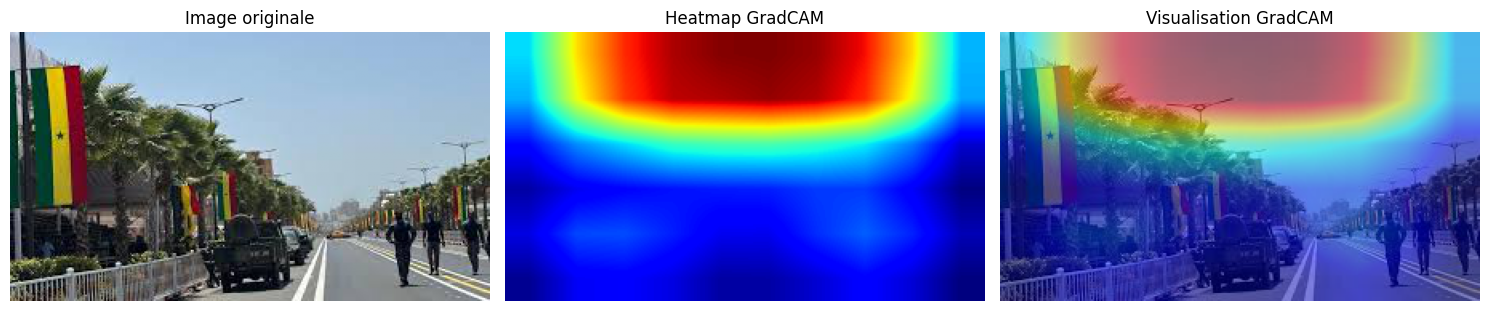

In [ ]:
# Appliquer GradCAM
target_layers = [model.resnet.layer4[-1]]  # Dernière couche de ResNet
cam = GradCAM(model=model, target_layers=target_layers)

# Obtenir la visualisation
grayscale_cam = cam(input_tensor=img_tensor.float(), targets=None)
grayscale_cam = grayscale_cam[0, :]

# Afficher le résultat
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# Titre descriptif basé sur la prédiction
title_prefix = f"GradCAM - Prédiction: {predicted_class_name.upper()} ({confidence:.1%})"

plt.figure(figsize=(16, 5))
plt.suptitle(title_prefix, fontsize=14, fontweight='bold', y=1.02)

plt.subplot(1, 3, 1)
plt.imshow(rgb_img)
plt.title('Image originale')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(grayscale_cam, cmap='jet')
plt.title('Heatmap GradCAM\n(zones rouges = zone importante pour la décision)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(visualization)
plt.title('Overlay GradCAM')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"\n💡 Interprétation: Le modèle regarde les zones en ROUGE pour justifier sa prédiction '{predicted_class_name}'")


In [66]:
# Vérifier les prédictions du modèle
from shared.config import CLASS_NAMES

with torch.no_grad():
    output = model(img_tensor.float())
    probabilities = torch.softmax(output, dim=1)[0]
    predicted_class_idx = torch.argmax(probabilities).item()
    predicted_class_name = CLASS_NAMES[predicted_class_idx]
    confidence = probabilities[predicted_class_idx].item()

# Afficher clairement les probabilités des deux classes
proba_dict = {name: float(probabilities[idx]) for idx, name in enumerate(CLASS_NAMES)}

print(f"🎯 Classe prédite: {predicted_class_name.upper()}")
print(f"📊 Confiance: {confidence:.2%}")
print(f"\n📈 Probabilités complètes:")
for class_name, prob in proba_dict.items():
    bar_length = int(prob * 40)
    bar = "█" * bar_length + "░" * (40 - bar_length)
    print(f"  {class_name:15} [{bar}] {prob:.2%}")


🎯 Classe prédite: NOT_FLOODED
📊 Confiance: 97.96%

📈 Probabilités complètes:
  flooded         [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 2.04%
  not_flooded     [███████████████████████████████████████░] 97.96%


In [67]:
# Inspecter la structure du checkpoint
checkpoint = torch.load('models/best_flood_classifier (1).pth', map_location=device)
print("Premier 10 clés du checkpoint:")
for i, key in enumerate(sorted(checkpoint.keys())[:15]):
    print(f"  {key}: {checkpoint[key].shape}")

print(f"\nTotal de clés: {len(checkpoint.keys())}")
print(f"\nCette architecture n'est PAS ResNet18 standard!")

Premier 10 clés du checkpoint:
  bn1.bias: torch.Size([64])
  bn1.num_batches_tracked: torch.Size([])
  bn1.running_mean: torch.Size([64])
  bn1.running_var: torch.Size([64])
  bn1.weight: torch.Size([64])
  conv1.weight: torch.Size([64, 3, 7, 7])
  fc.bias: torch.Size([2])
  fc.weight: torch.Size([2, 512])
  layer1.0.bn1.bias: torch.Size([64])
  layer1.0.bn1.num_batches_tracked: torch.Size([])
  layer1.0.bn1.running_mean: torch.Size([64])
  layer1.0.bn1.running_var: torch.Size([64])
  layer1.0.bn1.weight: torch.Size([64])
  layer1.0.bn2.bias: torch.Size([64])
  layer1.0.bn2.num_batches_tracked: torch.Size([])

Total de clés: 122

Cette architecture n'est PAS ResNet18 standard!
